# Ganga River Water Quality Classification using k-NN

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 1. Load Data
Load the raw water quality monitoring dataset from .

In [2]:
# --- 1. Load Data ---
df = pd.read_csv("Datasets/cleaned_stations.csv", skiprows=[1])
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1425, 36)


,state_name,temp_min,temp_max,do_min,do_max,ph_min,ph_max,conductivity_min,conductivity_max,bod_min,...,conductivity_avg,bod_range,bod_avg,nitrate_range,nitrate_avg,fecal_coliform_range,fecal_coliform_avg,total_coliform_range,total_coliform_avg,wqi_category
0,31.0,2.0,13.0,7.6,9.0,6.5,8.1,58.0,135.0,1.0,...,96.5,1.8,1.9,1.55,1.095,1490.0,855.0,680.0,1260.0,Poor
1,31.0,2.0,13.0,7.8,8.8,6.7,7.8,62.0,113.0,1.0,...,87.5,1.8,1.9,0.76,0.700,1490.0,855.0,1250.0,975.0,Poor
2,31.0,2.0,14.0,7.9,8.9,6.3,8.0,52.0,137.0,1.0,...,94.5,0.0,1.0,1.42,1.030,88.0,66.0,461.0,309.5,Poor
3,31.0,2.0,13.0,7.8,9.1,7.0,7.8,51.0,113.0,1.0,...,82.0,0.0,1.0,0.65,0.645,97.0,71.5,320.0,270.0,Poor
4,31.0,4.0,16.0,7.6,8.7,6.7,7.8,44.0,128.0,1.0,...,86.0,0.0,1.0,0.58,0.610,171.0,134.5,680.0,580.0,Poor


## 2. Data Overview
Inspect summary information, data types, and descriptive statistics.

In [3]:
# View DataFrame summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1425 entries, 0 to 1424
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state_name              1425 non-null   float64
 1   temp_min                1425 non-null   float64
 2   temp_max                1425 non-null   float64
 3   do_min                  1425 non-null   float64
 4   do_max                  1425 non-null   float64
 5   ph_min                  1425 non-null   float64
 6   ph_max                  1425 non-null   float64
 7   conductivity_min        1425 non-null   float64
 8   conductivity_max        1425 non-null   float64
 9   bod_min                 1425 non-null   float64
 10  bod_max                 1425 non-null   float64
 11  nitrate_min             1425 non-null   float64
 12  nitrate_max             1425 non-null   float64
 13  fecal_coliform_min      1425 non-null   float64
 14  fecal_coliform_max      1425 non-null   float64
 15

In [4]:
# View numerical column statistics
df.describe()

,state_name,temp_min,temp_max,do_min,do_max,ph_min,ph_max,conductivity_min,conductivity_max,bod_min,...,conductivity_range,conductivity_avg,bod_range,bod_avg,nitrate_range,nitrate_avg,fecal_coliform_range,fecal_coliform_avg,total_coliform_range,total_coliform_avg
count,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,1425.000000,...,1425.000000,1425.000000,1425.000000,1425.000000,1.425000e+03,1.425000e+03,1.425000e+03,1.425000e+03,1.425000e+03,1.425000e+03
mean,53.369825,20.019228,27.318877,5.876912,7.913544,13.167944,21.911495,307.402175,1275.803509,2.612189,...,968.401333,791.602842,2.866400,4.045389,1.419247e+04,7.490358e+03,7.482804e+04,4.143025e+04,3.594050e+05,1.864064e+05
std,24.674227,55.831321,6.103040,2.090816,1.934334,45.110344,108.500027,948.670801,4357.774045,15.539747,...,4057.882007,2414.225313,18.054328,10.308135,3.861483e+05,1.947481e+05,9.099175e+05,4.649626e+05,5.280835e+06,2.650381e+06
min,0.000000,0.300000,2.400000,0.300000,0.300000,2.000000,3.000000,1.000000,1.600000,0.000000,...,-0.300000,1.300000,-571.000000,0.000000,-1.230000e+00,0.000000e+00,0.000000e+00,1.710000e+00,0.000000e+00,2.000000e+00
25%,31.000000,15.000000,24.000000,5.100000,7.000000,7.000000,7.900000,130.000000,272.000000,1.000000,...,104.000000,209.500000,0.500000,1.500000,3.400000e-01,5.600000e-01,1.900000e+01,1.850000e+01,1.100000e+02,1.160000e+02
50%,50.000000,19.500000,29.000000,6.200000,8.000000,7.200000,8.200000,214.000000,478.000000,1.200000,...,227.000000,350.000000,1.000000,2.000000,1.100000e+00,9.900000e-01,1.330000e+02,1.245000e+02,6.800000e+02,8.165000e+02
75%,79.000000,23.000000,31.000000,7.100000,9.000000,7.500000,8.400000,331.000000,873.000000,2.100000,...,488.000000,612.000000,2.000000,3.000000,2.750000e+00,2.080000e+00,1.900000e+03,1.400000e+03,4.410000e+03,3.100000e+03
max,88.000000,2115.000000,39.000000,25.000000,28.000000,755.000000,1878.000000,34400.000000,54200.000000,572.000000,...,47742.000000,44300.000000,143.600000,286.500000,1.399220e+07,7.003900e+06,2.399780e+07,1.200110e+07,1.599930e+08,8.000350e+07


## 3. Remove Unwanted Columns
Drop non-predictive identifier columns such as  and .

In [5]:
# --- 3. Check Columns ---
df.head()

,state_name,temp_min,temp_max,do_min,do_max,ph_min,ph_max,conductivity_min,conductivity_max,bod_min,...,conductivity_avg,bod_range,bod_avg,nitrate_range,nitrate_avg,fecal_coliform_range,fecal_coliform_avg,total_coliform_range,total_coliform_avg,wqi_category
0,31.0,2.0,13.0,7.6,9.0,6.5,8.1,58.0,135.0,1.0,...,96.5,1.8,1.9,1.55,1.095,1490.0,855.0,680.0,1260.0,Poor
1,31.0,2.0,13.0,7.8,8.8,6.7,7.8,62.0,113.0,1.0,...,87.5,1.8,1.9,0.76,0.700,1490.0,855.0,1250.0,975.0,Poor
2,31.0,2.0,14.0,7.9,8.9,6.3,8.0,52.0,137.0,1.0,...,94.5,0.0,1.0,1.42,1.030,88.0,66.0,461.0,309.5,Poor
3,31.0,2.0,13.0,7.8,9.1,7.0,7.8,51.0,113.0,1.0,...,82.0,0.0,1.0,0.65,0.645,97.0,71.5,320.0,270.0,Poor
4,31.0,4.0,16.0,7.6,8.7,6.7,7.8,44.0,128.0,1.0,...,86.0,0.0,1.0,0.58,0.610,171.0,134.5,680.0,580.0,Poor


## 4. Preprocessing & Target Variable Classification
Convert feature columns to numeric types and derive the target variable  using Dissolved Oxygen (), Biological Oxygen Demand (), and Fecal Coliform ().

In [6]:
# --- 4. Preprocessing & Feature Engineering ---
# Convert parameter columns to numeric
for col in df.columns:
    if col != 'state_name':
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows missing essential target classification parameters
target_features = ['do_max', 'bod_max', 'fecal_coliform_max']
df.dropna(subset=target_features, inplace=True)

# WQI Classification Logic
def classify_wqi(row):
    do_max = row['do_max']
    bod_max = row['bod_max']
    fecal_coliform_max = row['fecal_coliform_max']

    if do_max > 6.5 and bod_max < 2 and fecal_coliform_max < 100:
        return 'Good'
    elif 5 < do_max <= 6.5 and 2 <= bod_max < 5 and 100 <= fecal_coliform_max < 1000:
        return 'Moderate'
    else:
        return 'Poor'

df['wqi_category'] = df.apply(classify_wqi, axis=1)
print("Target variable 'wqi_category' distribution:")
print(df['wqi_category'].value_counts())

Target variable 'wqi_category' distribution:
wqi_category
Poor        1164
Good         213
Moderate      48
Name: count, dtype: int64


## 5. Handle Missing Values
Check missing value counts, fill missing numeric values with column mean averages, and apply  on .

In [7]:
df.isna().sum()

state_name                0
temp_min                  0
temp_max                  0
do_min                    0
do_max                    0
ph_min                    0
ph_max                    0
conductivity_min          0
conductivity_max          0
bod_min                   0
bod_max                   0
nitrate_min               0
nitrate_max               0
fecal_coliform_min        0
fecal_coliform_max        0
total_coliform_min        0
total_coliform_max        0
fecal_streptococci_min    0
fecal_streptococci_max    0
temp_range                0
temp_avg                  0
do_range                  0
do_avg                    0
ph_range                  0
ph_avg                    0
conductivity_range        0
conductivity_avg          0
bod_range                 0
bod_avg                   0
nitrate_range             0
nitrate_avg               0
fecal_coliform_range      0
fecal_coliform_avg        0
total_coliform_range      0
total_coliform_avg        0
wqi_category        

In [8]:
print(f"Total Missing Values:{df.isna().sum().sum()}")

Total Missing Values:0


In [9]:
# --- 5. Handle Missing Values ---
features = [col for col in df.columns if ('_min' in col or '_max' in col)] + ['state_name']
X = df[features].copy()
y = df['wqi_category']

print(f"Total missing values before imputation in X: {X.isnull().sum().sum()}")
print(f"Total missing values before imputation in y: {y.isnull().sum().sum()}")

# Impute missing values for numerical columns using column mean
numeric_cols = X.select_dtypes(include=['number']).columns
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].mean())

# Label Encode categorical column (state_name)
if 'state_name' in X.columns:
    le = LabelEncoder()
    X['state_name'] = le.fit_transform(X['state_name'].astype(str))

print(f"\nTotal missing values remaining after imputation: {X.isnull().sum().sum()}")

Total missing values before imputation in X: 0
Total missing values before imputation in y: 0

Total missing values remaining after imputation: 0


## 6. Feature Scaling & Range Normalization
Make all feature column values fall within a consistent range using  (and  for explicit [0, 1] range scaling) to ensure optimal k-NN distance calculations.

In [10]:
# --- 6. Feature Scaling (Range Normalization) ---
# 1. StandardScaler (Standardization: mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. MinMaxScaler (Range Normalization: [0, 1])
minmax_scaler = MinMaxScaler(feature_range=(0, 1))
X_minmax = minmax_scaler.fit_transform(X)

print(f"Scaled feature matrix shape: {X_scaled.shape}")
print(f"MinMaxScaler feature range check - Min: {X_minmax.min()}, Max: {X_minmax.max():.1f}")

Scaled feature matrix shape: (1425, 19)
MinMaxScaler feature range check - Min: 0.0, Max: 1.0


## 7. Train k-NN Model
Split the dataset (80% training, 20% testing) with stratification and train the  (k=5).

In [11]:
# --- 7. Train the k-NN Model ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set shape: {X_train.shape}, Test set shape: {X_test.shape}")

Train set shape: (1140, 19), Test set shape: (285, 19)


In [12]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['Good','Moderate','Poor']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 8. Evaluate Model & Performance Metrics
Compute and print comprehensive performance metrics: Accuracy, Precision, Recall, F1-Score (weighted & macro), and the full Classification Report.

In [13]:
# --- 8. Model Evaluation ---
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision_w = precision_score(y_test, y_pred, average='weighted')
recall_w = recall_score(y_test, y_pred, average='weighted')
f1_w = f1_score(y_test, y_pred, average='weighted')

precision_m = precision_score(y_test, y_pred, average='macro')
recall_m = recall_score(y_test, y_pred, average='macro')
f1_m = f1_score(y_test, y_pred, average='macro')

print("=" * 50)
print("       k-NEAREST NEIGHBORS (k-NN) EVALUATION METRICS       ")
print("=" * 50)
print(f"Accuracy Score          : {accuracy:.4f} ({accuracy * 100:.3f}%)")
print(f"Weighted Precision      : {precision_w:.4f}")
print(f"Weighted Recall         : {recall_w:.4f}")
print(f"Weighted F1-Score       : {f1_w:.4f}")
print("-" * 50)
print(f"Macro Precision         : {precision_m:.4f}")
print(f"Macro Recall            : {recall_m:.4f}")
print(f"Macro F1-Score          : {f1_m:.4f}")
print("=" * 50)
print("Classification Report:")
print(classification_report(y_test, y_pred))

       k-NEAREST NEIGHBORS (k-NN) EVALUATION METRICS       
Accuracy Score          : 0.9018 (90.175%)
Weighted Precision      : 0.9005
Weighted Recall         : 0.9018
Weighted F1-Score       : 0.8955
--------------------------------------------------
Macro Precision         : 0.8987
Macro Recall            : 0.6774
Macro F1-Score          : 0.7436
Classification Report:
              precision    recall  f1-score   support

        Good       0.78      0.67      0.72        42
    Moderate       1.00      0.40      0.57        10
        Poor       0.92      0.97      0.94       233

    accuracy                           0.90       285
   macro avg       0.90      0.68      0.74       285
weighted avg       0.90      0.90      0.90       285



## 9. Confusion Matrix
Generate and display the Confusion Matrix visualization.

Confusion Matrix Table:
                 Pred Good  Pred Moderate  Pred Poor
Actual Good             28              0         14
Actual Moderate          0              4          6
Actual Poor              8              0        225


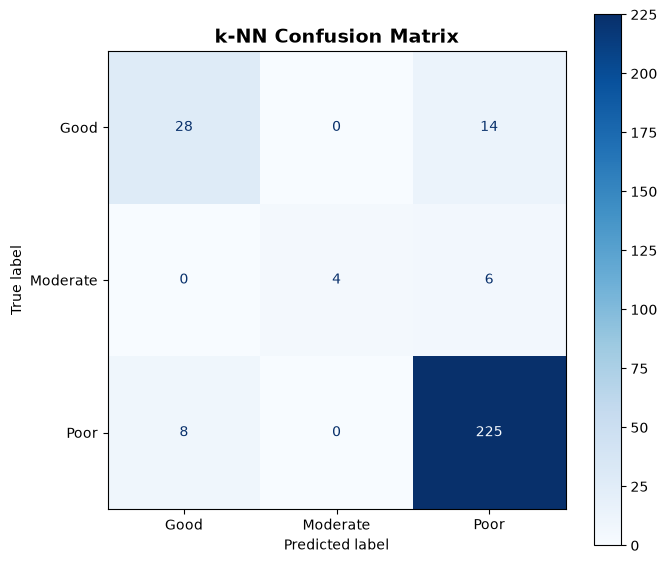

In [14]:
# --- 9. Confusion Matrix ---
labels = ['Good', 'Moderate', 'Poor']
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"Actual {l}" for l in labels], columns=[f"Pred {l}" for l in labels])

print("Confusion Matrix Table:")
print(cm_df)

# Visualizing Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('k-NN Confusion Matrix', fontsize=14, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

## 10. Save Model & Scaler Artifacts
Save the trained k-NN model and feature scaler to  directory for production deployment.

In [15]:
# --- 10. Save Model and Scaler ---
joblib.dump(model, 'models/knn_model.joblib')
joblib.dump(scaler, 'models/knn_scaler.joblib')
print("Saved models/knn_model.joblib")
print("Saved models/knn_scaler.joblib")

Saved models/knn_model.joblib
Saved models/knn_scaler.joblib
